# 03 · Wind comfort between the towers of Midtown Manhattan

**Question:** where is it too windy to sit, stand or walk comfortably?

Tall buildings pull fast wind down to the street and channel it along the avenues.
We run two wind analyses on 600 m × 600 m of Midtown Manhattan:

- **Wind speed** for the prevailing wind: one speed and one direction, in m/s.
- **Pedestrian wind comfort** (PWC): a comfort class for each cell, from all the hours
  of a typical year and a comfort criterion (here Lawson LDDC).

**Data.** Public buildings and trees for the area. With your own model, pass your layers instead.
Wind analyses use a finer tile grid (a step of 256 m, tiles overlap by half), so the same
area needs more jobs than a sun or comfort analysis.

In [1]:
import logging
import os

import matplotlib.pyplot as plt
import numpy as np

from infrared_sdk import InfraredClient, PwcModelRequest, WindModelRequest
from infrared_sdk.analyses.types import AnalysesName, PwcCriteria
from infrared_sdk.models import TimePeriod

import ir_plot as irp

os.environ["INFRARED_QUIET"] = "1"  # no progress lines
logging.getLogger("infrared_sdk").setLevel(logging.ERROR)  # no start-up notes
client = InfraredClient()  # reads INFRARED_API_KEY

## 1. Area and public layers

In [2]:
lon, lat = -73.9800, 40.7560
polygon = irp.site(lon, lat, width_m=600)
buildings = irp.cached_object("manhattan-buildings", lambda: client.buildings.get_area(polygon))
trees = irp.cached_object("manhattan-trees", lambda: client.vegetation.get_area(polygon))
heights = [a["height"] for a in buildings.attributes.values() if a.get("height")]
print(f"{len(buildings.buildings)} buildings (median {np.median(heights):.0f} m, "
      f"tallest {max(heights):.0f} m), {trees.total_trees} trees")

976 buildings (median 34 m, tallest 427 m), 6153 trees


## 2. The wind of a typical year

The public weather catalog gives the nearest station. We take every hour of the year.

In [3]:
station = client.weather.get_weather_file_from_location(lat=lat, lon=lon)[0]
year = TimePeriod(start_month=1, start_day=1, start_hour=0, end_month=12, end_day=31, end_hour=23)
hours = client.weather.filter_weather_data(identifier=station["uuid"], time_period=year)
speed = np.array([h.windSpeed for h in hours], dtype=float)
direction = np.array([h.windDirection for h in hours], dtype=float)

# The prevailing wind: the most frequent of 16 sectors, and its mean speed.
sector = np.round(direction / 22.5).astype(int) % 16
prevailing = int(np.bincount(sector[speed > 0], minlength=16).argmax())
prevailing_dir = int(prevailing * 22.5)
prevailing_speed = float(speed[(sector == prevailing) & (speed > 0)].mean())
print(f"{station['fileName']}: {len(hours)} hours; prevailing wind from {prevailing_dir}°, "
      f"mean {prevailing_speed:.1f} m/s")

USA_NY_New.York-Central.Park.Obs-Belvedere.Castle.725053_TMYx.2009-2023: 8760 hours; prevailing wind from 292°, mean 3.6 m/s


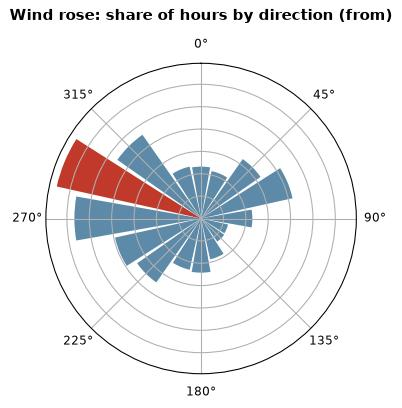

In [4]:
counts = np.bincount(sector[speed > 0], minlength=16)
fig = plt.figure(figsize=(4.2, 4.2))
ax = fig.add_subplot(projection="polar")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.bar(np.radians(np.arange(16) * 22.5), 100 * counts / counts.sum(), width=np.radians(20),
       color=["#c0392b" if i == prevailing else "#5d8aa8" for i in range(16)])
ax.set_yticklabels([])
ax.set_title("Wind rose: share of hours by direction (from)", pad=14)
plt.show()

## 3. Two wind analyses in one call

Wind speed takes one speed and one direction (whole degrees). PWC takes the hourly
speeds and directions of the window. Both use the same tile grid, so they share the uploads.

In [5]:
wind = WindModelRequest(analysis_type=AnalysesName.wind_speed,
                        wind_speed=prevailing_speed, wind_direction=prevailing_dir)
comfort = PwcModelRequest(analysis_type=AnalysesName.pedestrian_wind_comfort,
                          criteria=PwcCriteria.lawson_lddc,
                          wind_speed=speed.tolist(), wind_direction=direction.tolist())
for p in (wind, comfort):
    pv = client.preview_area(polygon, payload=p)
    print(f"{p.analysis_type}: {pv.tile_count} tiles, {pv.would_bill_jobs} jobs, "
          f"{pv.estimated_cost_tokens} tokens")

wind-speed: 9 tiles, 9 jobs, 90 tokens
pedestrian-wind-comfort: 9 tiles, 9 jobs, 90 tokens


In [6]:
speed_map, comfort_map = irp.cached("manhattan-wind", lambda: client.run_area_and_wait(
    [wind, comfort], polygon, buildings=buildings, vegetation=trees.features))

## 4. Wind speed

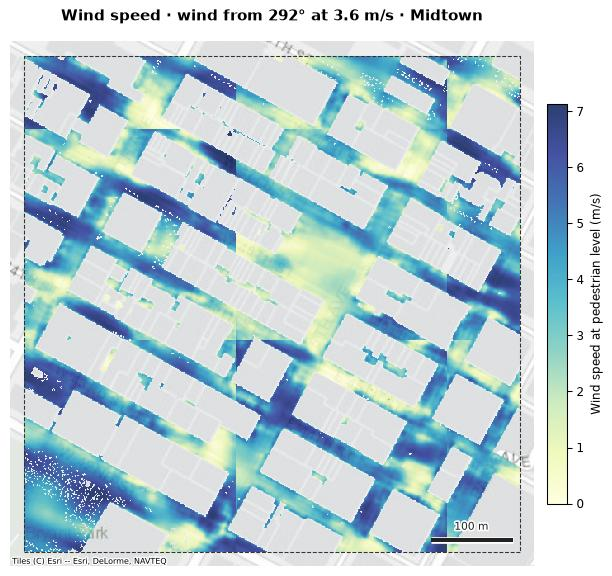

In [7]:
irp.map_grid(speed_map, polygon=polygon, vmin=0, label="Wind speed at pedestrian level (m/s)",
             title=f"Wind speed · wind from {prevailing_dir}° at {prevailing_speed:.1f} m/s · Midtown")
plt.show()

**What you see:** the wind comes from the west-north-west, almost along the cross
streets of the Manhattan grid. These streets channel it: fast bands (dark blue) run
along them. The avenues across the wind and the lee of the towers are calm (yellow).
Straight seams can show where two wind tiles join: the SDK keeps the centre 256 m of each tile.

## 5. Pedestrian wind comfort

The result holds class codes and their labels (`result.legend`). `irp.map_grid` draws one colour
for each class, from calm (green) to windy (red).

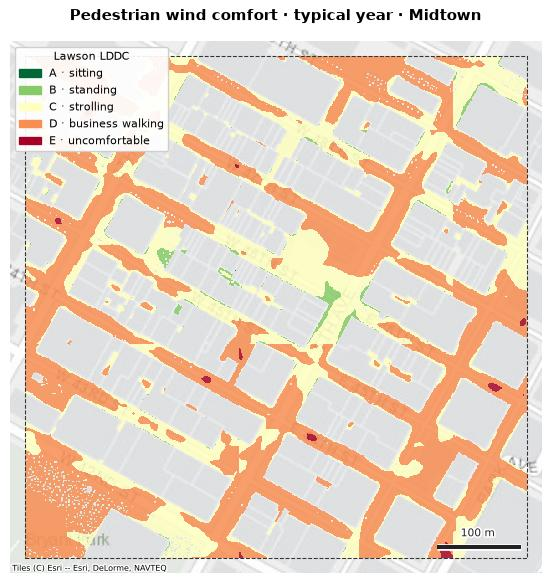

In [8]:
# Lawson LDDC classes (A is calmest). The SDK gives the codes; the names are the LDDC scale.
LDDC = {"A": "sitting", "B": "standing", "C": "strolling",
        "D": "business walking", "E": "uncomfortable"}
comfort_map.legend = [f"{c} · {LDDC.get(c, '')}" for c in comfort_map.legend]
irp.map_grid(comfort_map, polygon=polygon, label="Lawson LDDC",
             title="Pedestrian wind comfort · typical year · Midtown")
plt.show()

**What you see:** most of the open ground is class D (business walking) or C
(strolling). Small class E spots (uncomfortable) sit on the cross streets next to
tall towers. Class A (sitting) does not occur, and class B (standing) is rare: a few
sheltered corners of plazas and courtyards.

In [9]:
codes = comfort_map.values[np.isfinite(comfort_map.values)].astype(int)
share = np.bincount(codes, minlength=len(comfort_map.legend)) / codes.size
for label, s in zip(comfort_map.legend, share):
    print(f"{label:>28}: {100 * s:5.1f} % of the open ground")

                 A · sitting:   0.0 % of the open ground
                B · standing:   1.4 % of the open ground
               C · strolling:  34.5 % of the open ground
        D · business walking:  63.6 % of the open ground
           E · uncomfortable:   0.5 % of the open ground


## Next

- Try another criterion: `PwcCriteria` has Lawson, NEN 8100, VDI 3787 and Davenport.
- Guide, the analyses: <https://infrared.city/docs/sdk/1.0/#the-ten-analyses>
- Guide, tiling: <https://infrared.city/docs/sdk/1.0/#tiling>